# Calibration of probabilities for breast cancer dataset

This notebook studies the calibration of probabilistic classifiers using the Breast Cancer Wisconsin dataset.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

## 2. Load the Dataset

In [32]:
cancer = load_breast_cancer(as_frame=True)

X = cancer["data"]
y = cancer["target"].rename("target")

df = pd.concat([X, y], axis=1)

target = 0: malignant 

target = 1: benign

## 3. Exploratory Data Analysis (EDA)

### General describe

In [6]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 569
Number of variables: 31


In [7]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [9]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


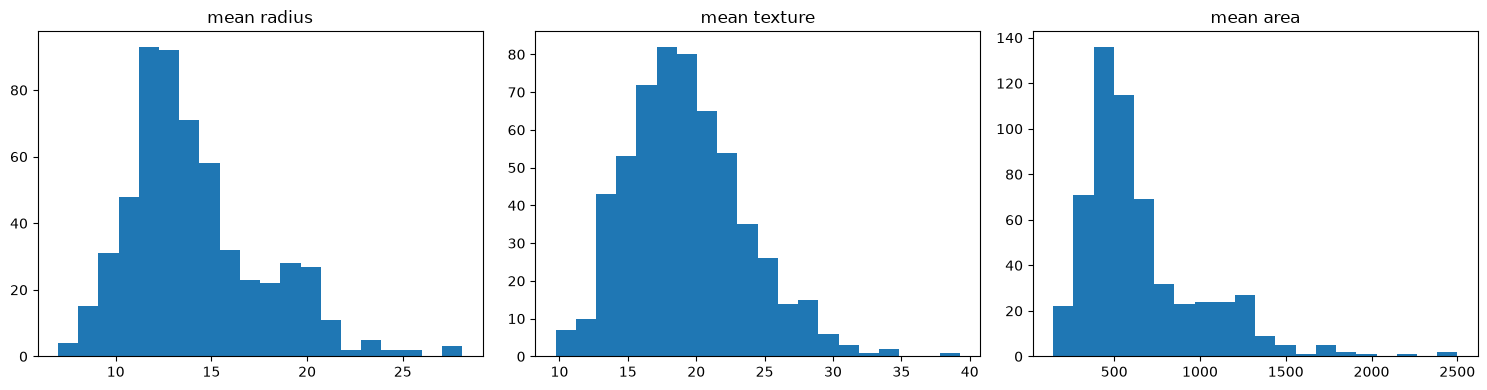

In [10]:
features = [
    "mean radius",
    "mean texture",
    "mean area"
]

plt.figure(figsize=(15,4))

for i, feature in enumerate(features):

    plt.subplot(1,3,i+1)

    plt.hist(df[feature], bins=20)

    plt.title(feature)

plt.tight_layout()
plt.show()

### Target distribution

In [11]:
target_summary = pd.DataFrame({
    "Count": df["target"].value_counts(),
    "Percentage": (df["target"].value_counts(normalize=True) * 100).round(2)
})

target_summary.index = ["Malignant", "Benign"]

target_summary

,Count,Percentage
Malignant,357,62.74
Benign,212,37.26


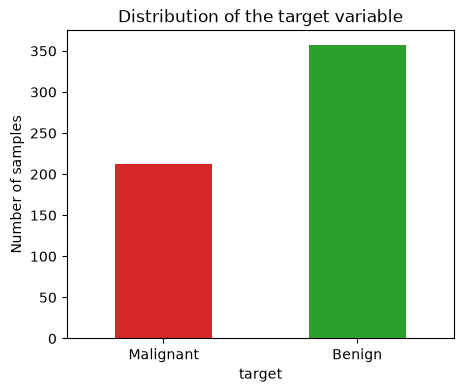

In [12]:
plt.figure(figsize=(5,4))

df["target"].value_counts().sort_index().plot(
    kind="bar",
    color=["#d62728", "#2ca02c"]
)

plt.xticks([0,1], ["Malignant", "Benign"], rotation=0)
plt.ylabel("Number of samples")
plt.title("Distribution of the target variable")

plt.show()

### Missing values

In [13]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [14]:
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


### Correlation matrix

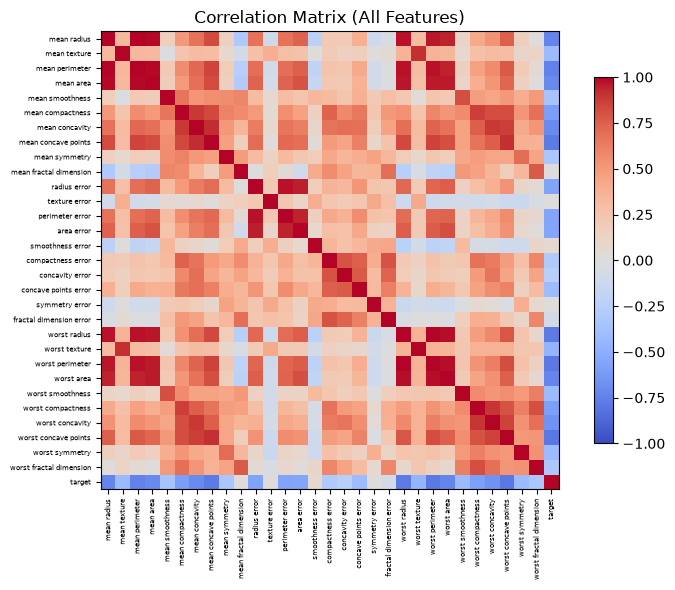

In [15]:
corr = df.corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr,
           cmap="coolwarm",
           vmin=-1,
           vmax=1,
           interpolation="nearest")

plt.colorbar(shrink=0.8)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=5
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=5
)

plt.title("Correlation Matrix (All Features)", fontsize=12)

plt.tight_layout()
plt.show()

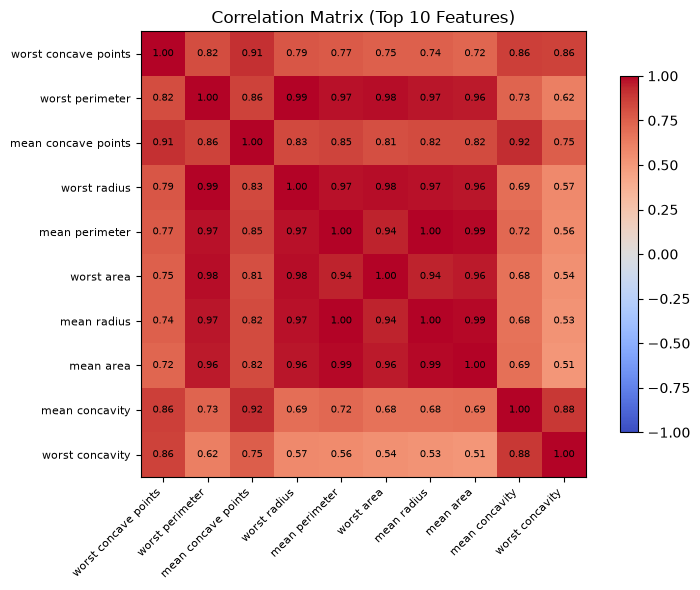

In [16]:
# Select the 10 features most correlated with the target
top_features = (
    df.corr()["target"]
    .abs()
    .sort_values(ascending=False)
    .index[1:11]       # exclude the target itself
)

corr_top = df[top_features].corr()

plt.figure(figsize=(8,6))

plt.imshow(
    corr_top,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

plt.colorbar(shrink=0.8)

plt.xticks(
    range(len(top_features)),
    top_features,
    rotation=45,
    ha="right",
    fontsize=8
)

plt.yticks(
    range(len(top_features)),
    top_features,
    fontsize=8
)

# Add correlation values
for i in range(len(corr_top)):
    for j in range(len(corr_top)):
        plt.text(
            j,
            i,
            f"{corr_top.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

plt.title("Correlation Matrix (Top 10 Features)", fontsize=12)

plt.tight_layout()
plt.show()

The Breast Cancer dataset contains **569 observations** and **30 numerical features**, together with a binary target variable indicating whether a tumor is malignant or benign.

The dataset is clean, with **no missing values**, so no data cleaning is required before training the models.

The target classes are relatively balanced, with approximately **63% benign** and **37% malignant** samples, making the dataset suitable for binary classification.

The distributions of the selected features show different ranges and slight skewness, suggesting that feature scaling will be beneficial for models such as Logistic Regression.

Finally, the correlation analysis reveals that several features are highly correlated with each other, particularly those describing tumor size and shape. Many of these features also show a strong relationship with the target variable, indicating that they are likely to be informative for classification.

## 4. Data Preprocessing

### Feature Matrix and Target Vector

In [17]:
# Separate features and target

X = df.drop(columns="target")
y = df["target"]

In [18]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


### Train, Calibration and Test Split

In [19]:
x_train, x_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

In [20]:
x_cal, x_test, y_cal, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

80 train, 20 test, 20 calibration

stratify=y beacause we have the same proportion of target in each groups

In [21]:
print("Training set:", x_train.shape)
print("Calibration set:", x_cal.shape)
print("Test set:", x_test.shape)

Training set: (341, 30)
Calibration set: (114, 30)
Test set: (114, 30)


#### Class Distribution after the Split

In [22]:
print("Training")
print(y_train.value_counts(normalize=True))

print("\nCalibration")
print(y_cal.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Training
target
1    0.627566
0    0.372434
Name: proportion, dtype: float64

Calibration
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64

Test
target
1    0.622807
0    0.377193
Name: proportion, dtype: float64


## 5. Logistic regression

#### Standardization

In [ ]:
scaler = StandardScaler()

# Only on the training set
X_train_scaled = scaler.fit_transform(x_train)

# And apply to the others
X_cal_scaled = scaler.transform(x_cal)
X_test_scaled = scaler.transform(x_test)

#### Train Logistic Regression

In [24]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### Predicted Probabilities

In [ ]:
y_prob_test_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
# probability that tumor is benign on test set

In [26]:
y_prob_cal_lr = log_reg.predict_proba(X_cal_scaled)[:, 1]
# probability that tumor is benign on calibration set

#### Predicted Classes

In [27]:
y_pred_test_lr = log_reg.predict(X_test_scaled)

### 5.1 Evaluation before Calibration

In [28]:
accuracy_lr = accuracy_score(y_test, y_pred_test_lr)
logloss_lr = log_loss(y_test, y_prob_test_lr)
brier_lr = brier_score_loss(y_test, y_prob_test_lr)

print(f"Accuracy:    {accuracy_lr:.4f}")
print(f"Log-loss:    {logloss_lr:.4f}")
print(f"Brier score: {brier_lr:.4f}")

Accuracy:    0.9912
Log-loss:    0.0719
Brier score: 0.0190


Accuracy: higher values indicate better classification performance.

Log-loss: lower values indicate better probabilistic predictions.

Brier score: lower values indicate better calibrated probability estimates.

#### Reliability diagram before calibration

In [29]:
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_ids = np.digitize(y_prob_test_lr, bin_edges[1:-1])

mean_predicted_prob = []
fraction_of_positives = []

for i in range(n_bins):

    mask = bin_ids == i

    if np.sum(mask) > 0:
        mean_predicted_prob.append(
            np.mean(y_prob_test_lr[mask])
        )

        fraction_of_positives.append(
            np.mean(y_test.to_numpy()[mask])
        )

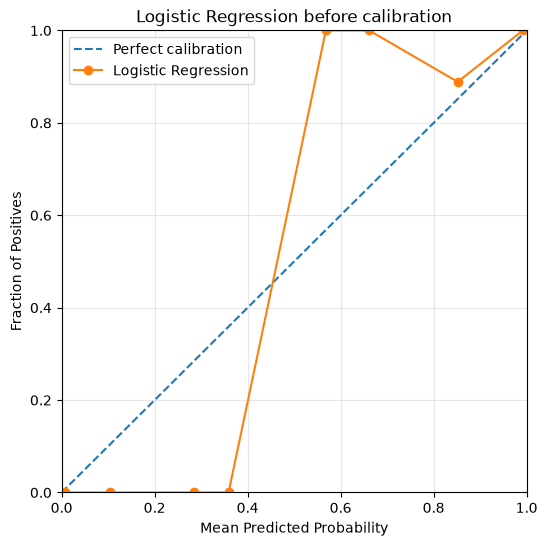

In [31]:
plt.figure(figsize=(6, 6))

# Perfect line --> perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

# Logistic Regression curve
plt.plot(
    mean_predicted_prob,
    fraction_of_positives,
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Logistic Regression before calibration")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Predicted probabilities deviate from the perfect calibration line. This suggests that the Logistic Regression model is not perfectly calibrated.